In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PowerTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(tmin=-2, tmax=2, resample=None, fmin=0.1, fmax=None)
dataset = BNCI2014008()

In [3]:
subject, session, run = 2, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.


<RawArray | 10 x 347704 (1358.2 s), ~26.5 MB, data loaded>

Effective window size : 1.000 (s)


/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/mne/viz/utils.py:137: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


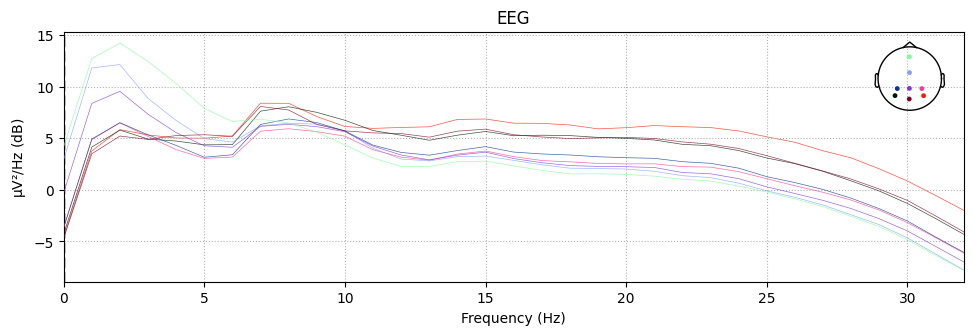

In [4]:
import matplotlib.pyplot as plt

raw.compute_psd(fmax=32).plot()
plt.show()

In [5]:
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-2.000 – 2.000 sec
Baseline,off


    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...


/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/mne/viz/utils.py:137: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


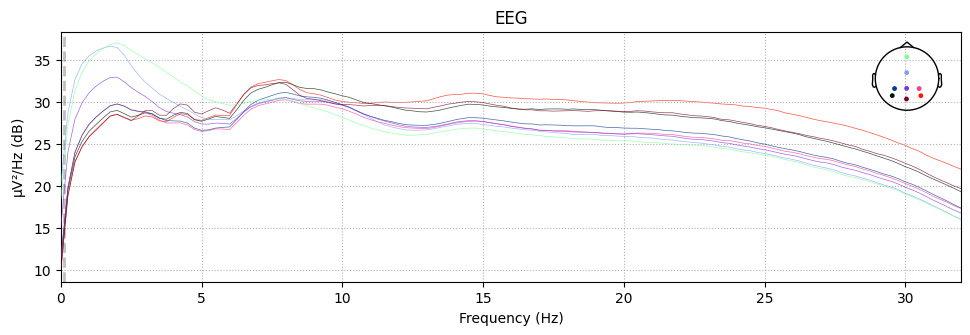

In [6]:
epochs.compute_psd(fmax=32).plot()
plt.show()

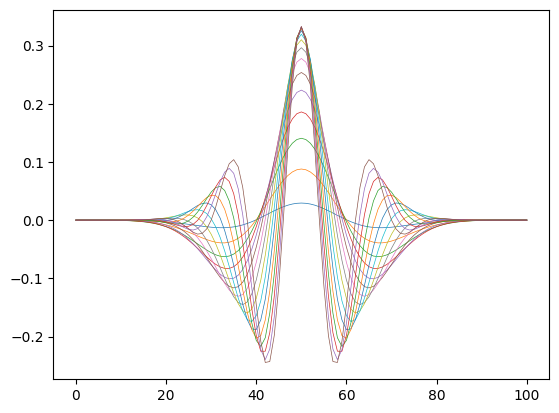

In [7]:
sfreq=32
n_freqs=16
freqs = np.linspace(0.5, 16, n_freqs)
n_cycles = freqs/4
wavelets = morlet(epochs.info['sfreq'],
                  freqs, n_cycles, zero_mean=True)
for i in range(n_freqs):
    plt.plot(np.real(wavelets[i]), linewidth=0.5)
plt.show()

In [8]:
epochs_tfr = tfr_morlet(epochs, freqs, n_cycles, return_itc=False, average=False,
                    output='complex', verbose=True, n_jobs=-1, decim=int(epochs.info['sfreq']//sfreq))
epochs_tfr.data = np.abs(epochs_tfr.data)
epochs_tfr.crop(-0.5, 1)
epochs_tfr.apply_baseline((-0.5, -0.1), 'logratio')
epochs_tfr.apply_baseline((-0.5, -0.1), 'mean')
epochs_tfr.crop(0, 0.8)
epochs.decimate(epochs.info['sfreq']//sfreq)
epochs_tfr

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:    6.8s remaining:   11.3s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:    7.6s remaining:    4.6s


Not setting metadata


[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    8.8s finished


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: mean)


/tmp/ipykernel_39028/2150127399.py:8: RuntimeWarning: The measurement information indicates a low-pass frequency of 128.0 Hz. The decim=8 parameter will result in a sampling frequency of 32.0 Hz, which can cause aliasing artifacts.
  epochs.decimate(epochs.info['sfreq']//sfreq)


<EpochsTFR | time : [0.000000, 0.812500], freq : [0.500000, 16.000000], epochs : 4200, channels : 8, ~110.8 MB>

No baseline correction applied


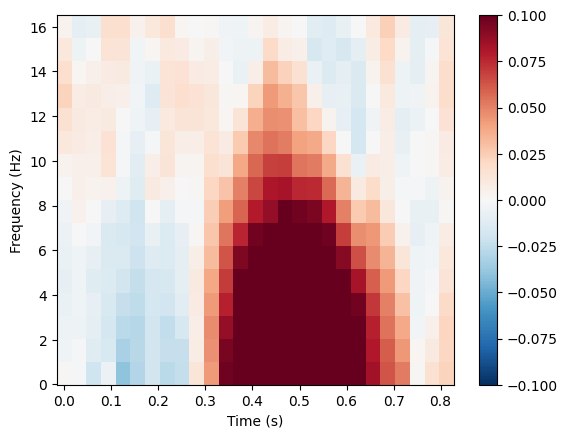

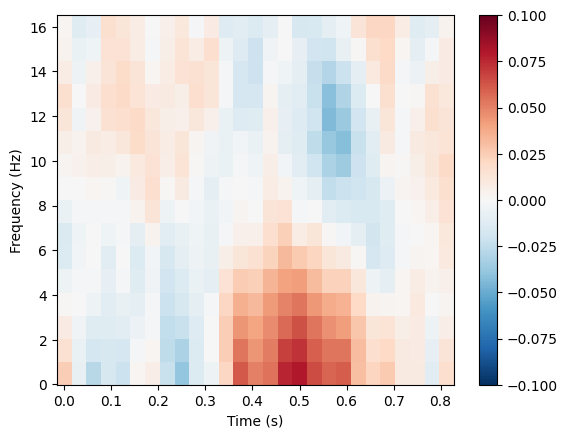

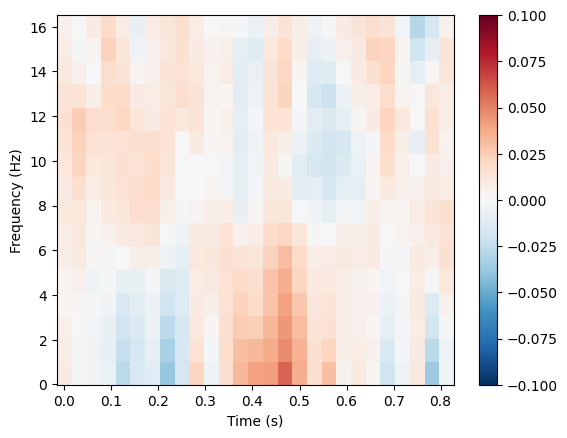

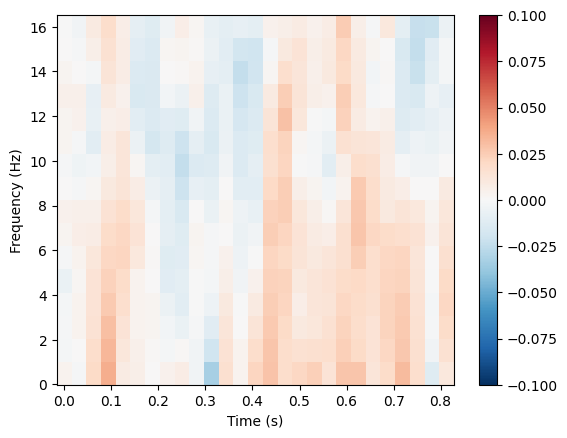

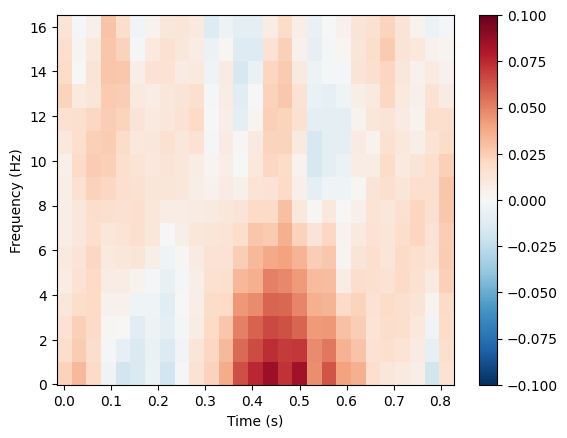

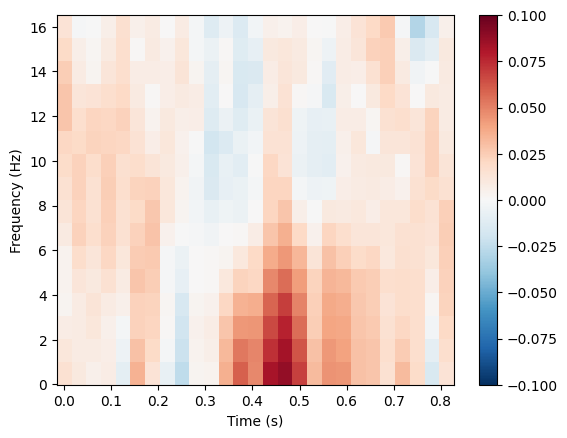

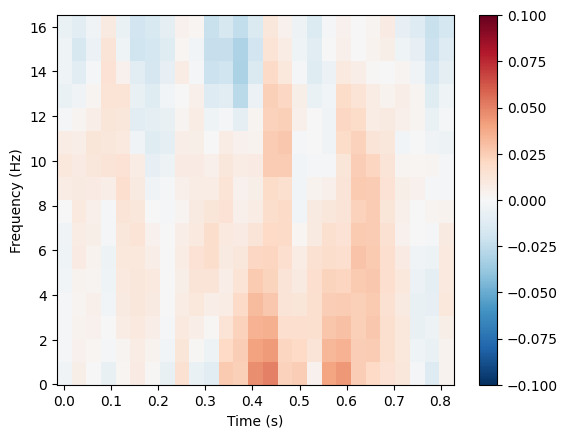

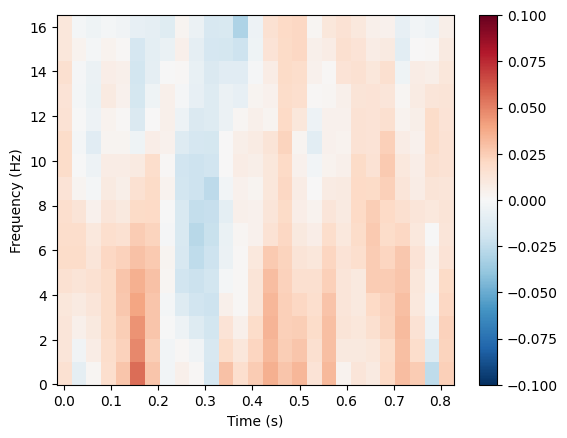

In [9]:
class_names = np.unique(labels)
avg_target = epochs_tfr['Target'].average()
#fig = avg_target.plot_topo(show=False)
#fig.set_size_inches(16, 16)
avg_target.plot(vmin=-0.1, vmax=0.1)
plt.show()

No baseline correction applied


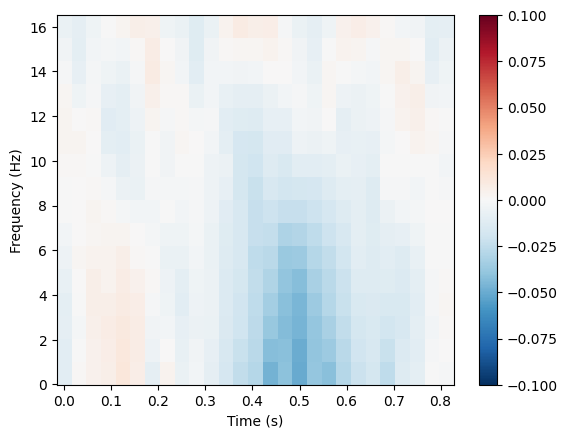

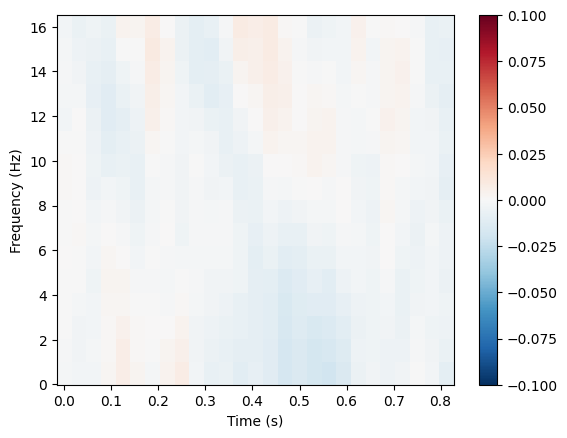

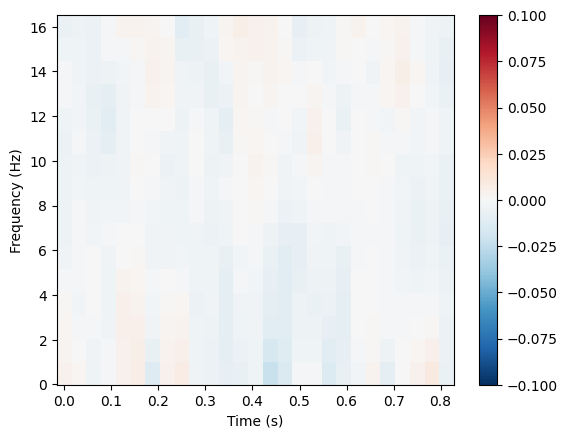

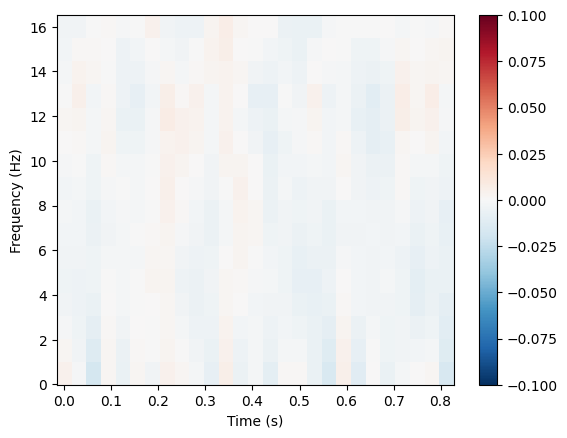

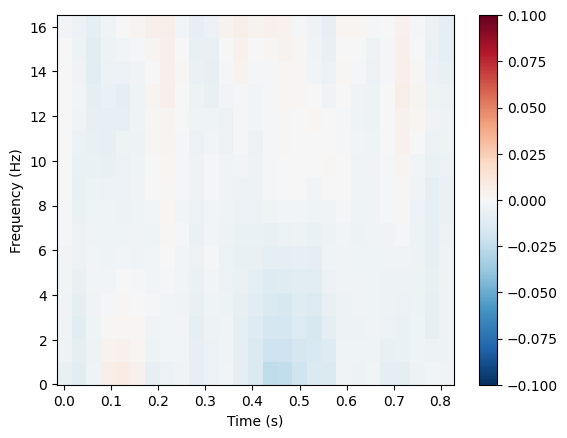

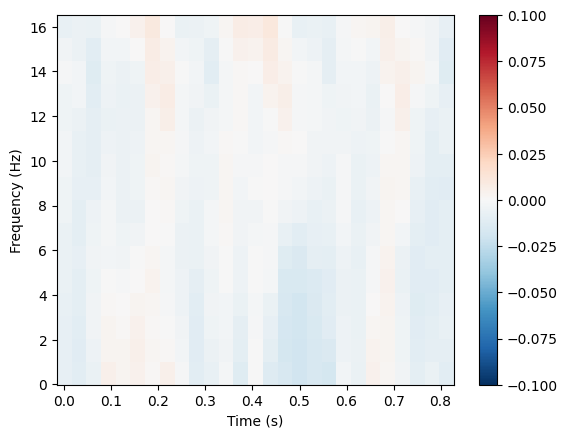

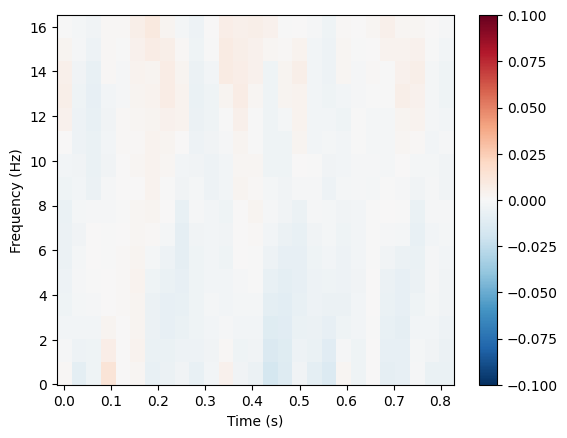

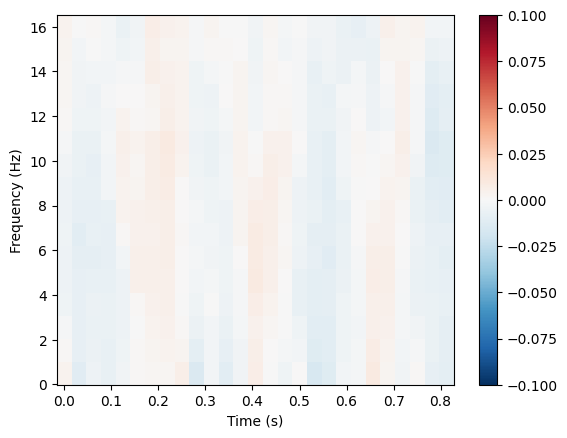

In [10]:
avg_non_target = epochs_tfr['NonTarget'].average()
#fig = avg_non_target.plot_topo(show=False)
#fig.set_size_inches(16, 16)
figs = avg_non_target.plot(vmin=-0.1, vmax=0.1);
plt.show()

No baseline correction applied


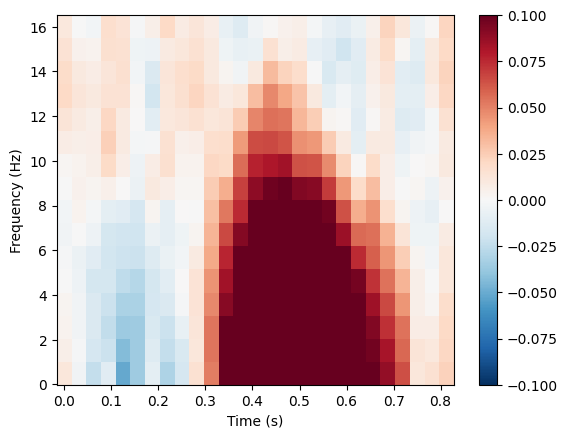

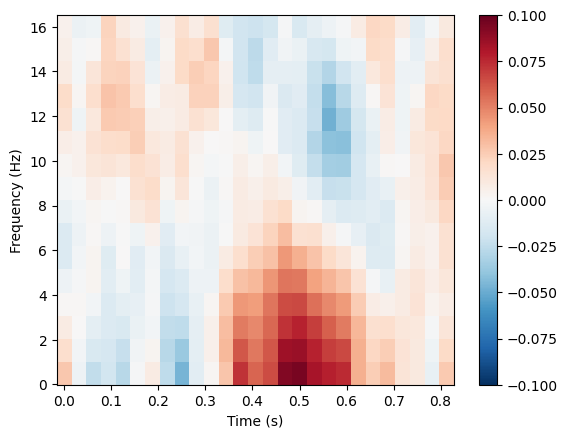

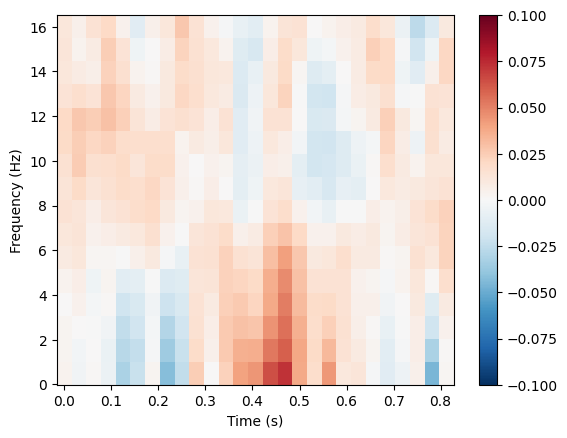

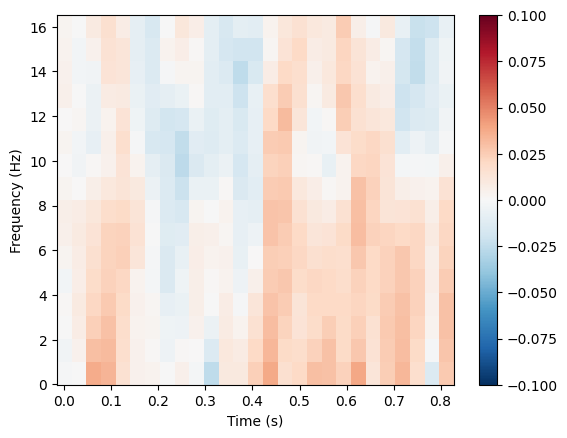

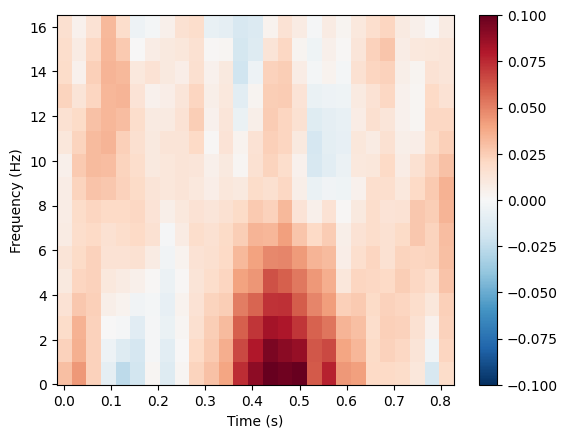

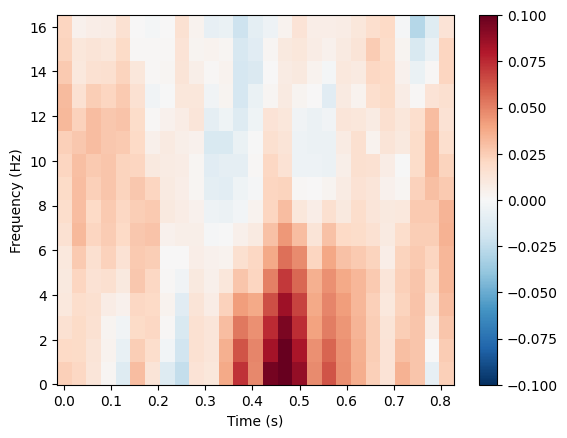

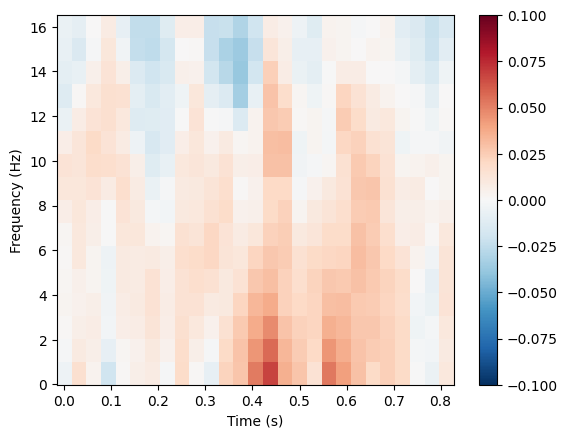

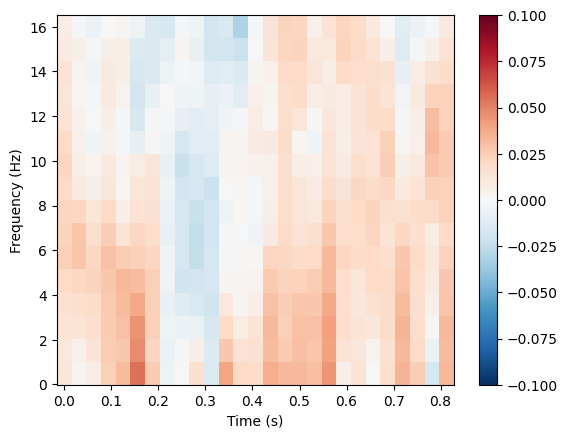

In [11]:
from mne import combine_evoked
from mne.viz import plot_tfr_topomap

contrast = combine_evoked([avg_target, avg_non_target], weights = [1,-1])
#fig = contrast.plot_topo(show=False)
#fig.set_size_inches(16, 16)
contrast.plot(vmin=-0.1, vmax=0.1)
plt.show()

In [12]:
#epochs_data_flat = epochs.data.flatten()
#sns.jointplot(x=np.real(epochs_data_flat), y=np.imag(epochs_data_flat),kind="hex")

In [13]:
split = len(epochs)//2
epochs_train = epochs_tfr[:split]
epochs_test = epochs_tfr[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [14]:
X_train = epochs_train.data.astype(np.float32)
y_train = labels_train
X_test = epochs_test.data.astype(np.float32)
y_test = labels_test

In [15]:
X_train -= np.mean(X_train, axis=0)[np.newaxis,:,:,:]
X_train /= np.std(X_train, axis=0)[np.newaxis,:,:,:]
X_test -= np.mean(X_train, axis=0)[np.newaxis,:,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:,:]

In [16]:
import tensorly as tl
try:
    tl.set_backend('jax')
except AttributeError:
    tl.set_backend('jax')

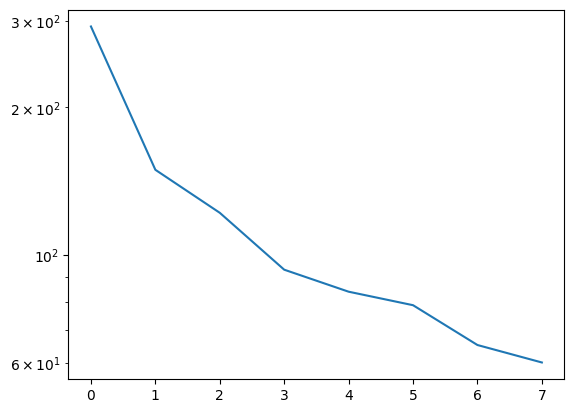

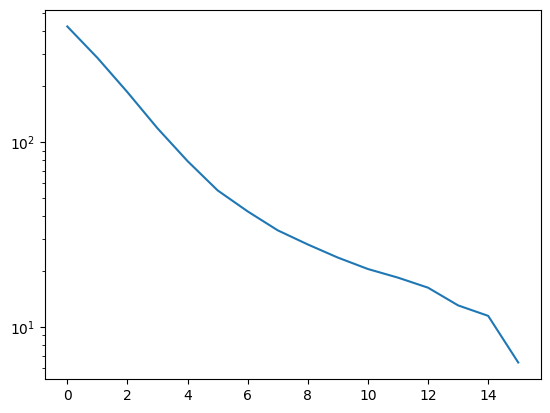

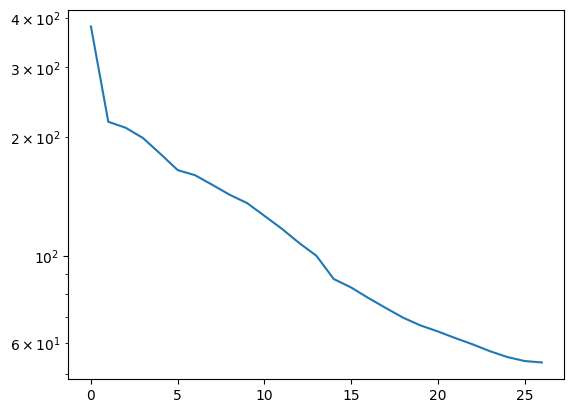

In [17]:
from tensorly.base import unfold
import jax.scipy.linalg

unfold1 = unfold(X_train, 1)[:,:20000]
U,s,V = jax.scipy.linalg.svd(unfold1)
plt.plot(s)
plt.yscale('log')
plt.show()
unfold2 = unfold(X_train, 2)[:,:20000]
U,s,V = jax.scipy.linalg.svd(unfold2)
plt.plot(s)
plt.yscale('log')
plt.show()
unfold3 = unfold(X_train, 3)[:,:20000]
U,s,V = jax.scipy.linalg.svd(unfold3)
plt.plot(s)
plt.yscale('log')
plt.show()

In [18]:
hoda = HODA(max_iter=32, rank=(4,4,4), tol=0, initialize ='identity', verbose=True, 
            shrinkage=(0.5,0.5,0.5))
hoda.fit(X_train,y_train)

[0/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=3.0171e+00
[1/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=2.7975e+00
[2/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=2.4081e+00
[3/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=2.3609e+00
[4/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=1.9633e+00
[5/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=2.2991e+00
[6/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=1.9760e+00
[7/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=2.2653e+00
[8/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=2.3987e+00
[9/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=2.4297e+00
[10/32]  shrinkage[0]=0.3000  shrinkage[1]=0.3000  shrinkage[2]=0.3000  step=2.4427e+00
[11/32]  shrinkage[0]=0.3000  shrinkage[1]

HODA(max_iter=32, rank=(4, 4, 4), shrinkage=(0.3, 0.3, 0.3), tol=0,
     verbose=True)

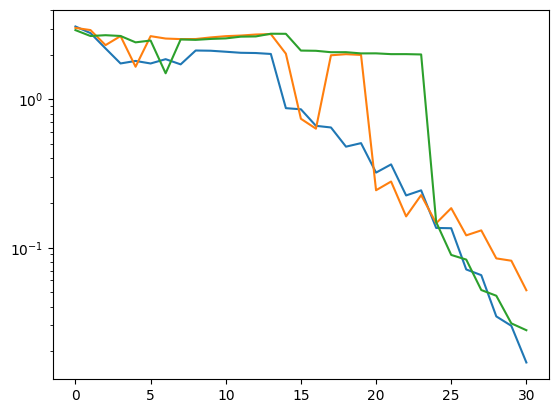

In [19]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

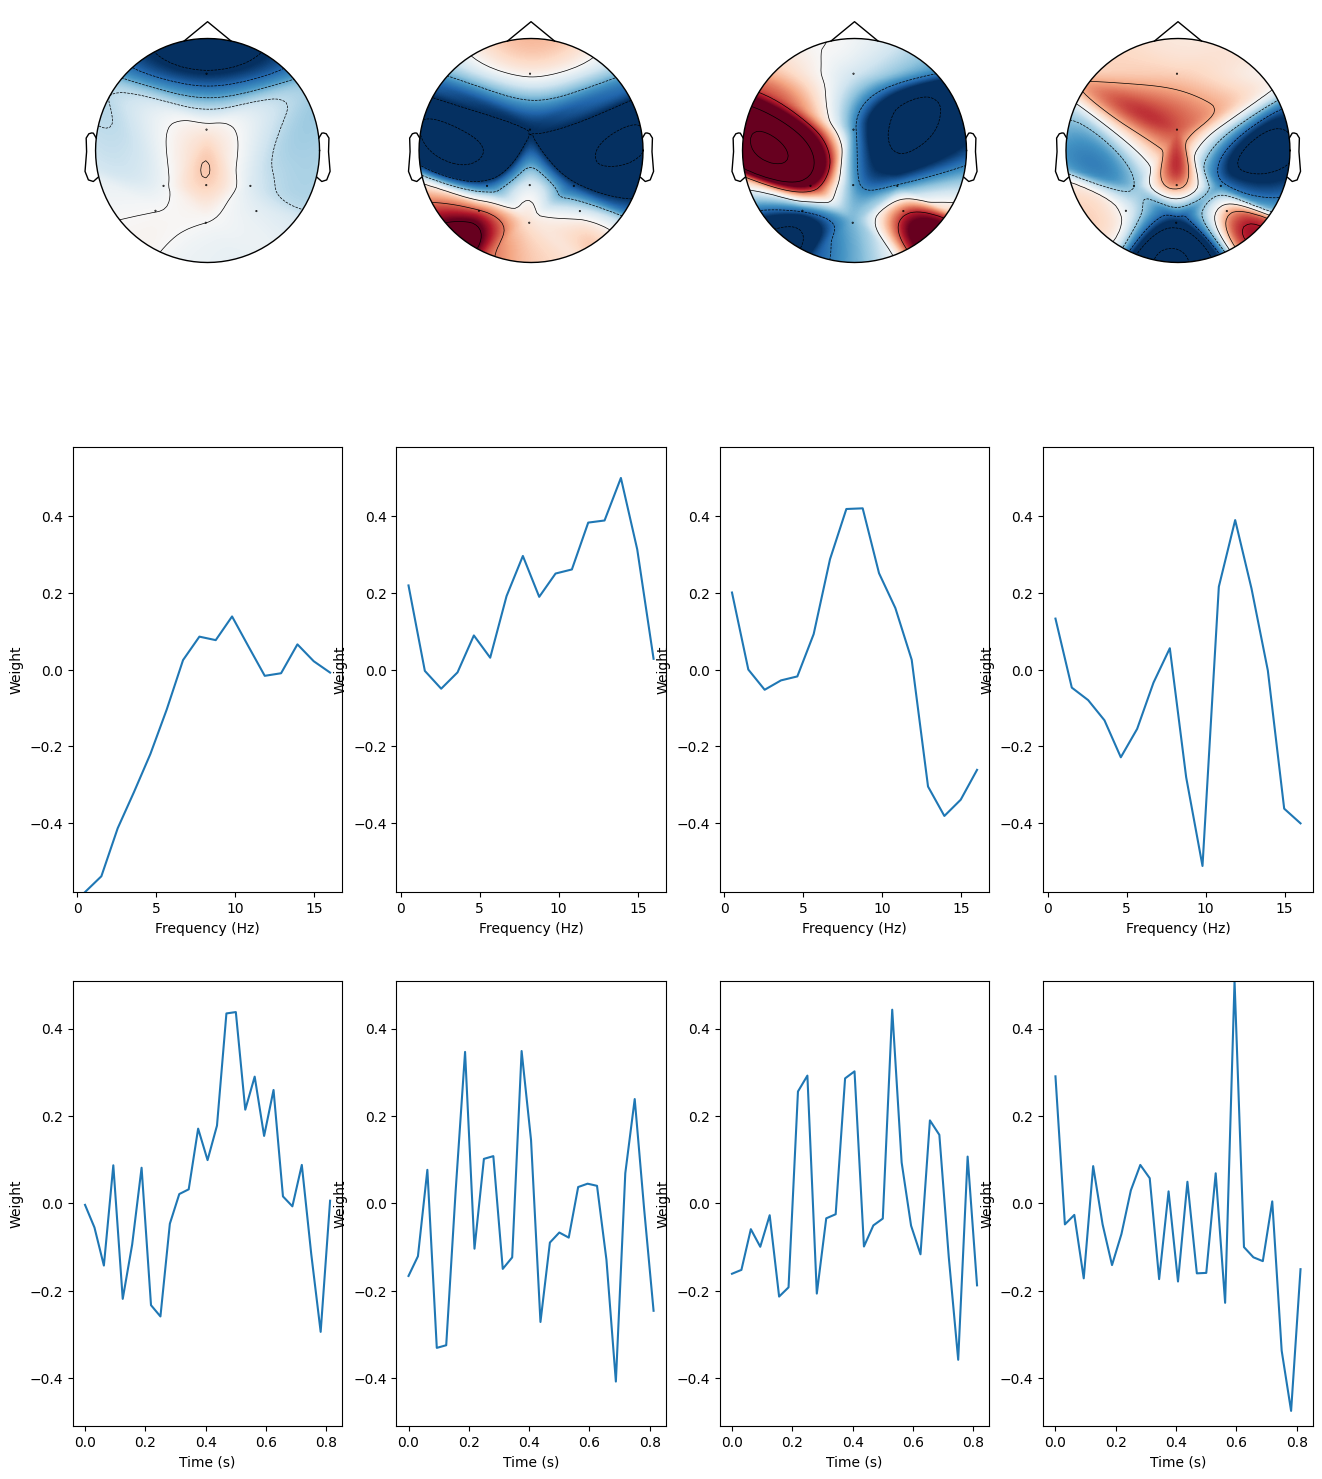

In [20]:
fig, axs = plt.subplots(3,max(hoda.rank), figsize=(16,6*3))
sp_rank = min(hoda.rank[0], len(epochs.ch_names))
for i in range(sp_rank):
    w = hoda.projs_[0][:,i]
    if sp_rank >1:
        plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(hoda.projs_[1]))
for i in range(hoda.rank[1]):
    w = hoda.projs_[1][:,i]
    axs[1,i].plot(freqs, w)
    axs[1,i].set_xlabel('Frequency (Hz)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
vmax = np.max(np.abs(hoda.projs_[2]))
for i in range(hoda.rank[2]):
    w = hoda.projs_[2][:,i]
    axs[2,i].plot(epochs_tfr.times, w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])
plt.show()

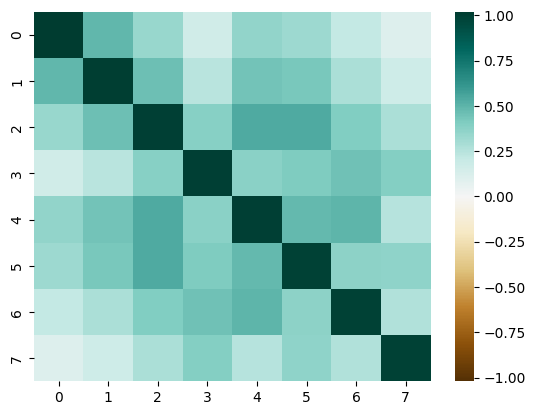

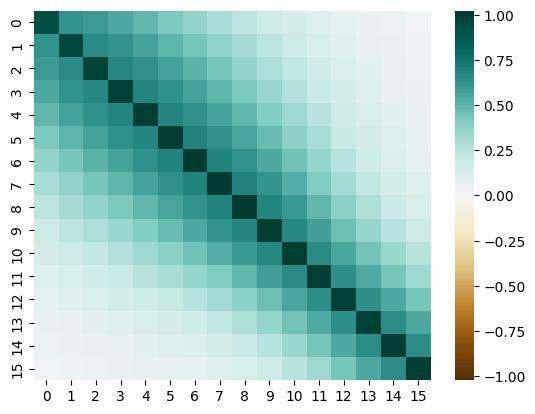

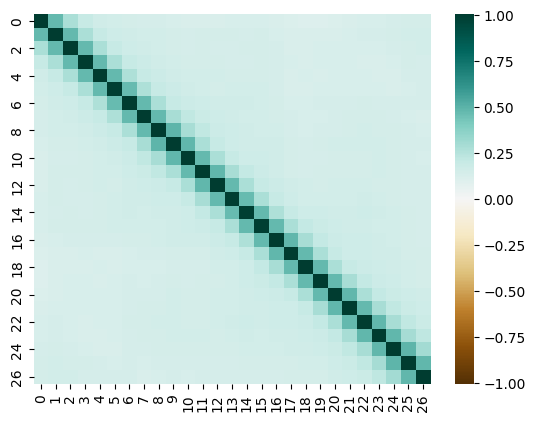

In [21]:
for k in range(3):
    cov = hoda.scatter_w_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

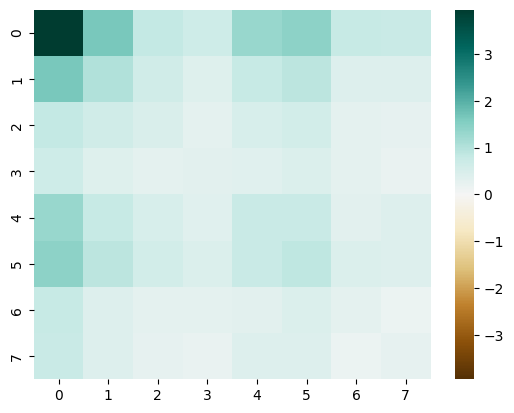

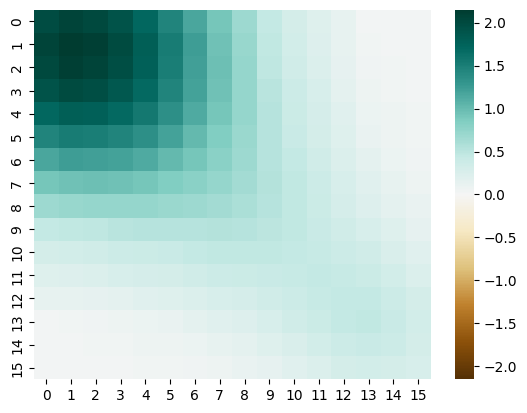

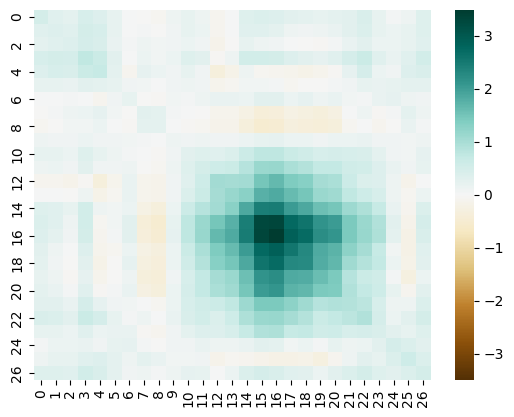

In [22]:
for k in range(3):
    cov = hoda.scatter_b_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

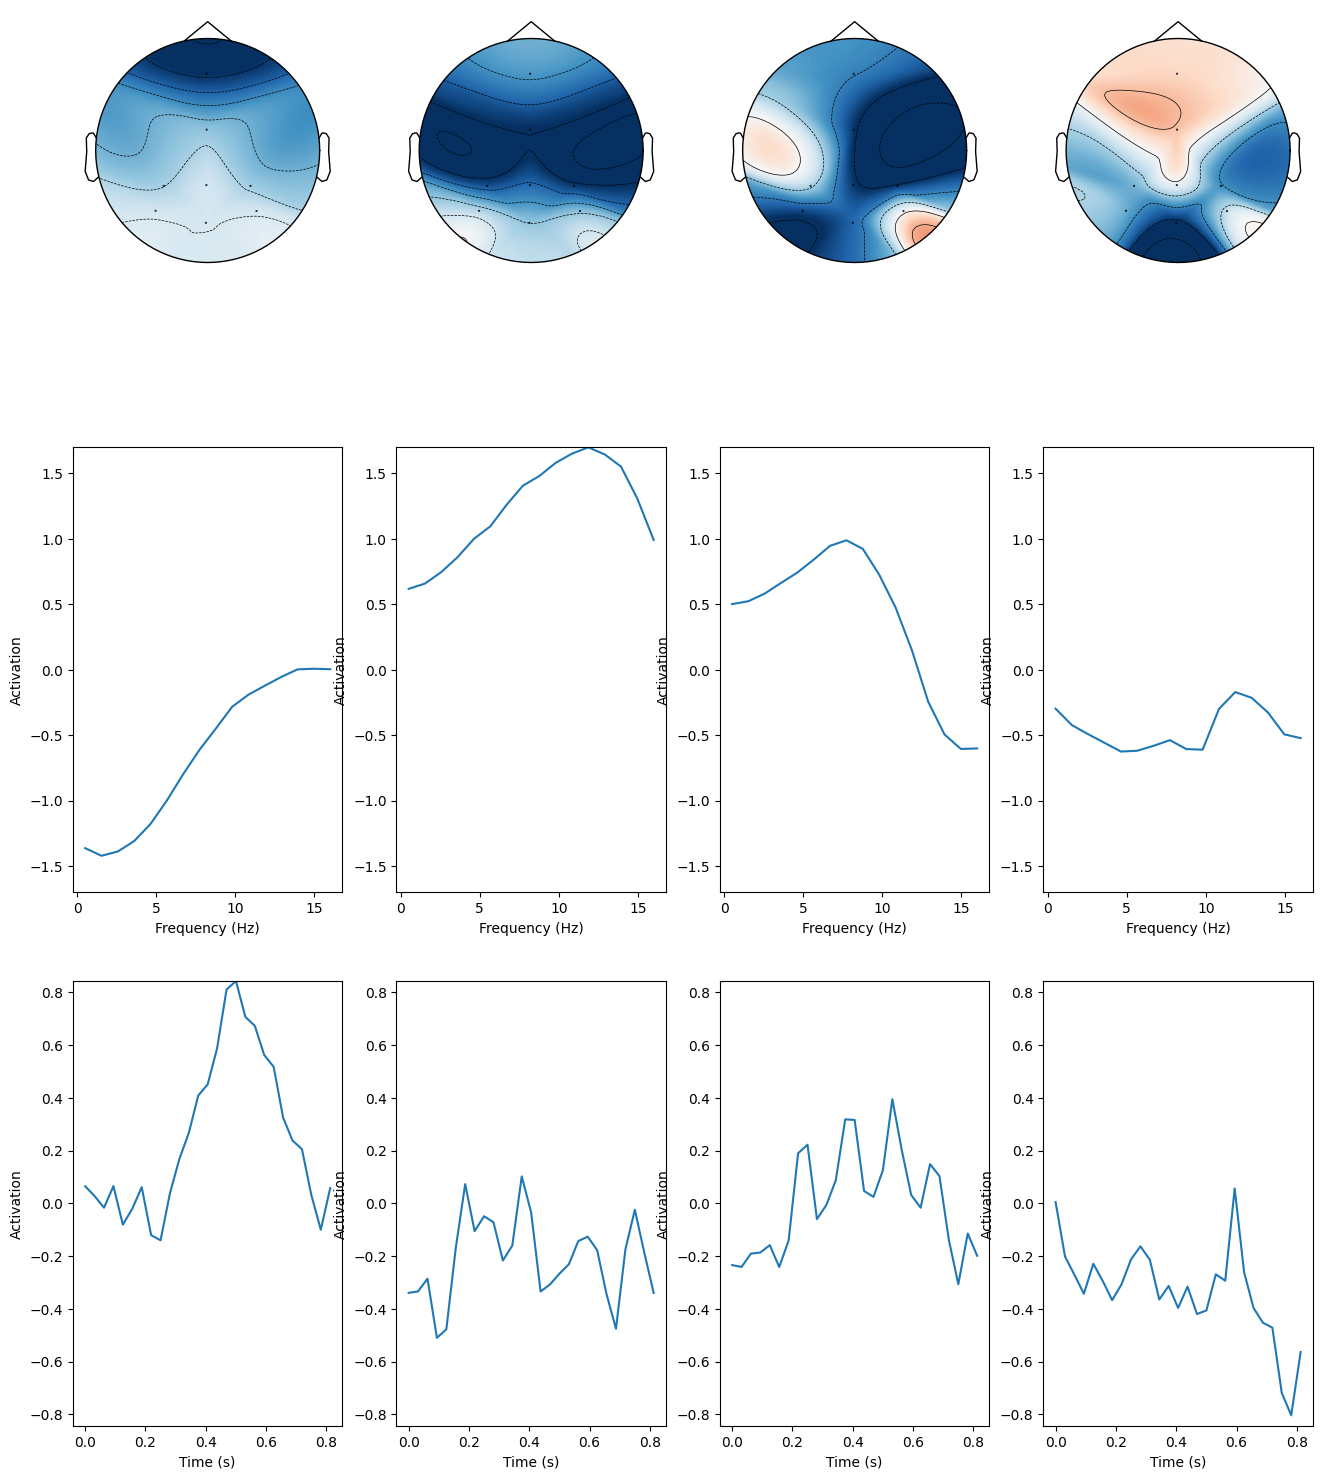

In [23]:
fig, axs = plt.subplots(3,max(hoda.rank), figsize=(16,6*3))
aps = [hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]
for i in range(sp_rank):
    w = aps[0][:,i]
    if sp_rank > 1:
        plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank[1]):
    w = aps[1][:,i]
    axs[1,i].plot(freqs, w)
    axs[1,i].set_xlabel('Frequency (Hz)')
    axs[1,i].set_ylabel('Activation')
    axs[1,i].set_ylim([-vmax, vmax])
vmax = np.max(np.abs(aps[2]))
for i in range(hoda.rank[2]):
    w = aps[2][:,i]
    axs[2,i].plot(epochs_tfr.times, w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Activation')
    axs[2,i].set_ylim([-vmax, vmax])
plt.show()

In [24]:
Xt_train = hoda.transform(tl.tensor(X_train))
Xt_test = hoda.transform(tl.tensor(X_test))

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

#classifier = LDA(solver='lsqr', shrinkage='auto')
classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()
print(classifier.coef_)

[[ 1.86736337e-01 -5.14066087e-02  1.03515931e-01  3.57732850e-02
  -8.31164797e-05  1.76395051e-01 -1.78668507e-01 -4.98455504e-03
  -1.18859177e-01 -9.11505914e-02 -9.69400326e-02 -7.11061878e-02
  -1.78618565e-01 -3.34051342e-02 -2.18465979e-01 -2.34425924e-01
   9.33120790e-02  3.26149513e-02 -9.69705178e-02  3.18688796e-02
   5.15220403e-03 -4.89231162e-03  1.03228792e-01  1.16391681e-01
   3.61631959e-02 -1.25714387e-01  9.37231726e-02  3.61946284e-02
  -7.32447818e-02 -2.41548011e-02  9.75370005e-02  1.12002897e-01
   9.87474691e-02  1.10744582e-01 -7.06298700e-03  9.65141098e-02
  -5.82011808e-03  3.31770484e-02  2.41112623e-02 -2.11507941e-01
   4.52038911e-02  1.10522274e-01  1.72004491e-01  1.19639892e-01
   1.09294707e-02  0.00000000e+00  2.50931535e-01  8.36665498e-02
  -9.67109287e-03 -2.85171810e-02  1.08708718e-01 -5.88372822e-02
  -1.03992511e-01  0.00000000e+00  4.77267941e-02 -2.84241414e-02
   3.59862699e-02  0.00000000e+00 -4.08113248e-02 -1.21055346e-02
  -3.49057

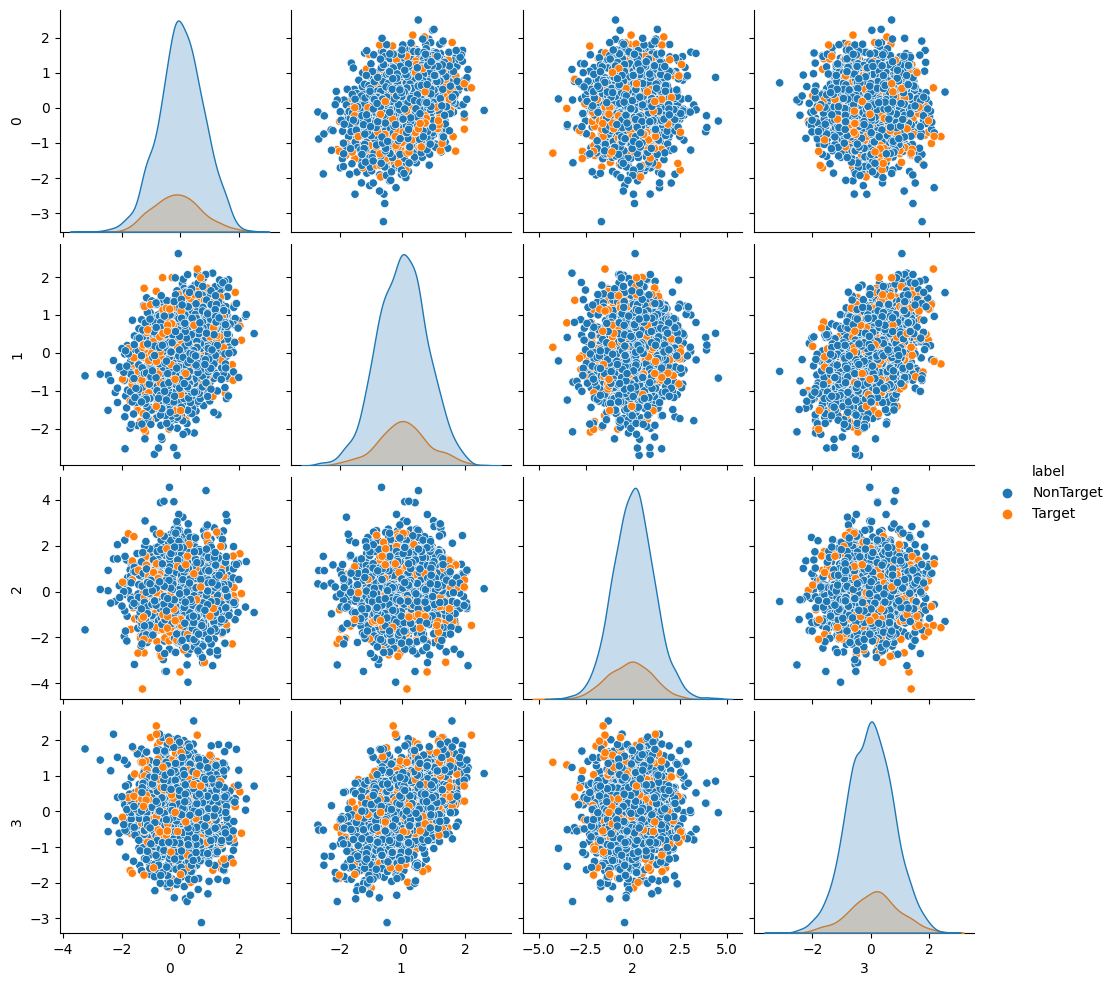

In [26]:
import seaborn as sns
import pandas as pd
Xt_train = hoda.transform(tl.tensor(X_train))
n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
sns.pairplot(df_train, hue='label')
plt.show()

In [27]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.7666873469387755

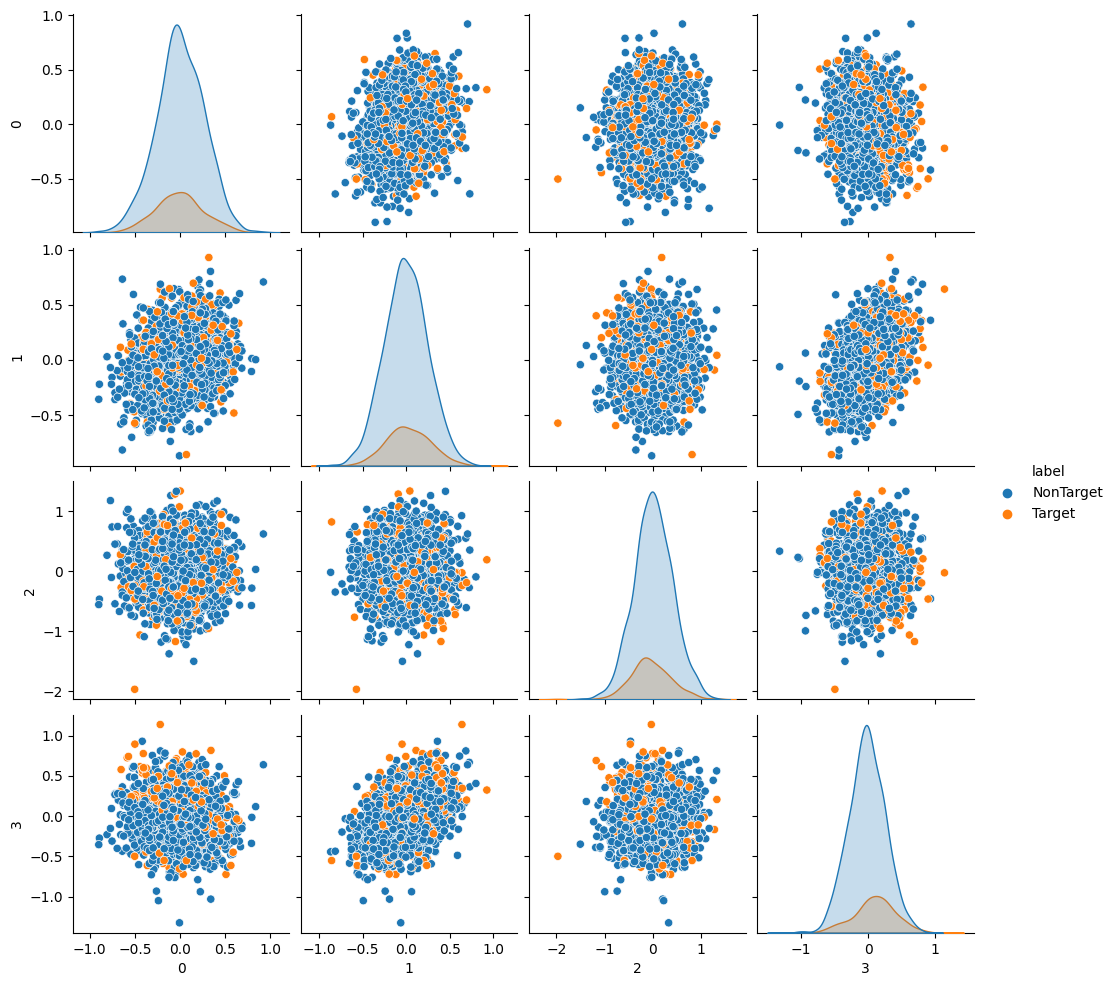

In [28]:
Xt_test = hoda.transform(tl.tensor(X_test))
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
sns.pairplot(df_test, hue='label')
plt.show()

In [29]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.6554236734693877